#  **Bacterial adaptation project**
## This project is a fragment from a complete bachelor's thesis project about the adaptation of *E. coli*  to grow on a defined cuture medium using a turbidostat. The data is from one of the trials of the main adaptation experiment that lasted for over 11 days. In this projec I process the experimental data, the analyze the accuracy of the data, evaluate the performance of the experiment and finally search for evidence of bacterial adaptation.

In [71]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import seaborn as sns

In [72]:
#Create the DataFrames
file1= "/content/drive/MyDrive/Colab Notebooks/adaptacion_04_07.txt"
file2= "/content/drive/MyDrive/Colab Notebooks/adaptacion_04_07_v2.txt"
file3= "/content/drive/MyDrive/Colab Notebooks/calibrations.xlsx"
df1= pd.read_csv(file1,sep="\t")
df2= pd.read_csv(file2,sep="\t")
df3= pd.read_excel(file3)


In [73]:
df3

,Voltage2,OD2,Voltage7,OD7
0,1.54,0.085,1.62,0.106
1,1.51,0.107,1.60,0.222
2,1.44,0.234,1.56,0.086
3,1.41,0.208,1.48,0.435
4,1.36,0.220,1.48,0.264
5,1.30,0.388,1.47,0.203
6,1.22,0.440,1.44,0.237
7,1.14,0.548,1.25,0.541
8,1.11,0.437,1.22,0.460
9,0.99,0.669,1.15,0.674


In [74]:
df1

,1,87.835938,0.059191,0.057191,0.006406,0.000083
0,2,87.835938,1.857128,1.529957,0.844672,0.010905
1,3,87.835938,2.820896,2.788041,1.270985,0.016408
2,4,87.835938,0.061740,0.058239,0.005834,0.000075
3,5,87.835938,0.059636,0.057729,0.006011,0.000078
4,6,87.835938,0.059347,0.057622,0.005626,0.000073
...,...,...,...,...,...,...
123202,4,847909.080616,0.063122,0.058239,0.005108,0.000065
123203,5,847909.080616,0.059902,0.057729,0.004184,0.000054
123204,6,847909.080616,0.059572,0.057622,0.004022,0.000051
123205,7,847909.080616,1.565082,1.550409,0.139656,0.001788


In [75]:
#Select the columns relevant for the analysis
df1= df1.rename(columns={"1":"Sensor", "87.835938":"Time","0.057191":"Median"}) #Where median refers to the median voltage signal from a sample taken on a time window of aproximately 1 minute
df2= df2.rename(columns={"1":"Sensor", "84.04508":"Time","0.057191":"Median"})
df1 = df1.loc[:,["Sensor","Time","Median"]]
df2 = df2.loc[:,["Sensor","Time","Median"]]
df1

,Sensor,Time,Median
0,2,87.835938,1.529957
1,3,87.835938,2.788041
2,4,87.835938,0.058239
3,5,87.835938,0.057729
4,6,87.835938,0.057622
...,...,...,...
123202,4,847909.080616,0.058239
123203,5,847909.080616,0.057729
123204,6,847909.080616,0.057622
123205,7,847909.080616,1.550409


In [76]:
#Convert time values seconds to hours
df1["Time"]= df1["Time"]/3600
df2["Time"]= df2["Time"]/3600+235.530300

In [77]:
df1

,Sensor,Time,Median
0,2,0.024399,1.529957
1,3,0.024399,2.788041
2,4,0.024399,0.058239
3,5,0.024399,0.057729
4,6,0.024399,0.057622
...,...,...,...
123202,4,235.530300,0.058239
123203,5,235.530300,0.057729
123204,6,235.530300,0.057622
123205,7,235.530300,1.550409


In [78]:
#Concatenate both DataFrames and select channel 2 and 7
df_total= pd.concat([df1,df2])
df_total= df_total.reset_index(drop=True)
df_sensor2= df_total[df_total["Sensor"]==2]
df_sensor7= df_total[df_total["Sensor"]==7]

In [79]:
#Inspect and search for errors on the complete Data Frame
print(df_total.info())
print(df_total.isna().sum())
print(df_total.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146646 entries, 0 to 146645
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sensor  146646 non-null  int64  
 1   Time    146646 non-null  float64
 2   Median  146646 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 3.4 MB
None
Sensor    0
Time      0
Median    0
dtype: int64
0


In [80]:
df_sensor2

,Sensor,Time,Median
0,2,0.024399,1.529957
8,2,0.041065,1.427678
16,2,0.057731,1.448134
24,2,0.074397,1.519729
32,2,0.091062,1.509501
...,...,...,...
146607,2,285.113856,0.660591
146615,2,285.130799,0.660591
146623,2,285.147743,0.660591
146631,2,285.164687,0.660591


Text(0.5, 1.0, 'Sensor 2')

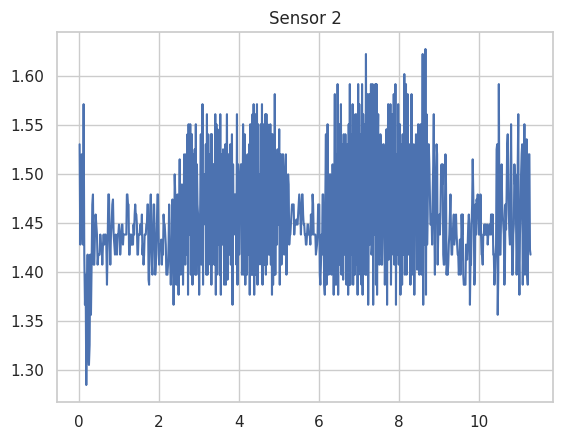

In [81]:
#Visualize channel 2 data to verify data accuracy
plt.plot(df_sensor2["Time"][:800],df_sensor2["Median"][:800])
plt.title("Sensor 2")

## The voltage signal recorded by sensor 2 has a lot of noise so I will not be using it for the analysis.

Text(0, 0.5, 'Voltage')

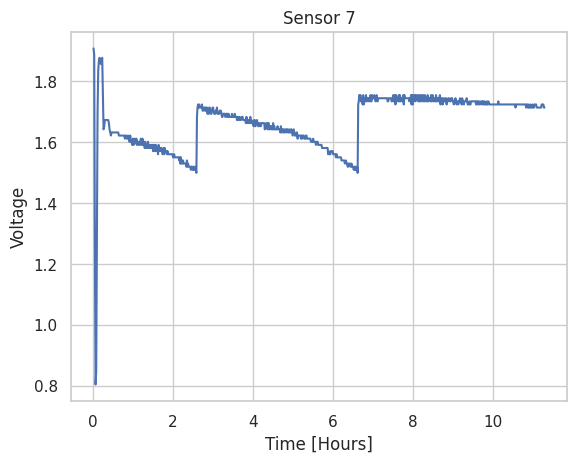

In [82]:
#Visualize channel 7 data to verify accuracy
plt.plot(df_sensor7["Time"][:800],df_sensor7["Median"][:800])
plt.title("Sensor 7")
plt.xlabel("Time [Hours]")
plt.ylabel("Voltage")

## The voltage signal recorded by sensor 7 works almost as expected for the experiment. At the begining there is some interference due to human errors while setting up the experiment but after that the data shows the espected behavior for bacterial growth and the automatic dilutions.


In [84]:
#Crop the begining of the signal
df_channel7 = df_sensor7[7:]
df_channel7

,Sensor,Time,Median
61,7,0.141060,1.836783
69,7,0.157726,1.867465
77,7,0.174392,1.877693
85,7,0.191058,1.867465
93,7,0.207723,1.857238
...,...,...,...
146612,7,285.113856,0.660606
146620,7,285.130799,0.660606
146628,7,285.147743,0.660606
146636,7,285.164687,0.660606


In [85]:
df_channel7["Time"]= df_channel7["Time"]-0.14106
df_channel7

/tmp/ipykernel_1043/1637527506.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_channel7["Time"]= df_channel7["Time"]-0.14106


,Sensor,Time,Median
61,7,1.030556e-07,1.836783
69,7,1.666597e-02,1.867465
77,7,3.333151e-02,1.877693
85,7,4.999790e-02,1.867465
93,7,6.666345e-02,1.857238
...,...,...,...
146612,7,2.849728e+02,0.660606
146620,7,2.849897e+02,0.660606
146628,7,2.850067e+02,0.660606
146636,7,2.850236e+02,0.660606


## To translate from a voltage signal to optical density I will create a linear model usig data priviously obtained from a calibration of the channel 7 from the turbidostat.

In [87]:
def linear_model(voltage, od, data):
  coef = np.polyfit(od, voltage, 1)
  a,b=coef
  return (data-b)/a

In [88]:
#Translate voltage signal to Optial Density
df_channel7["OD"]= linear_model(df3["Voltage7"],df3["OD7"],df_channel7["Median"])


/tmp/ipykernel_1043/1599515071.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_channel7["OD"]= linear_model(df3["Voltage7"],df3["OD7"],df_channel7["Median"])


# **Optical density plot for the first day of the adaptation experiment**

Text(0.5, 1.0, 'Day 1')

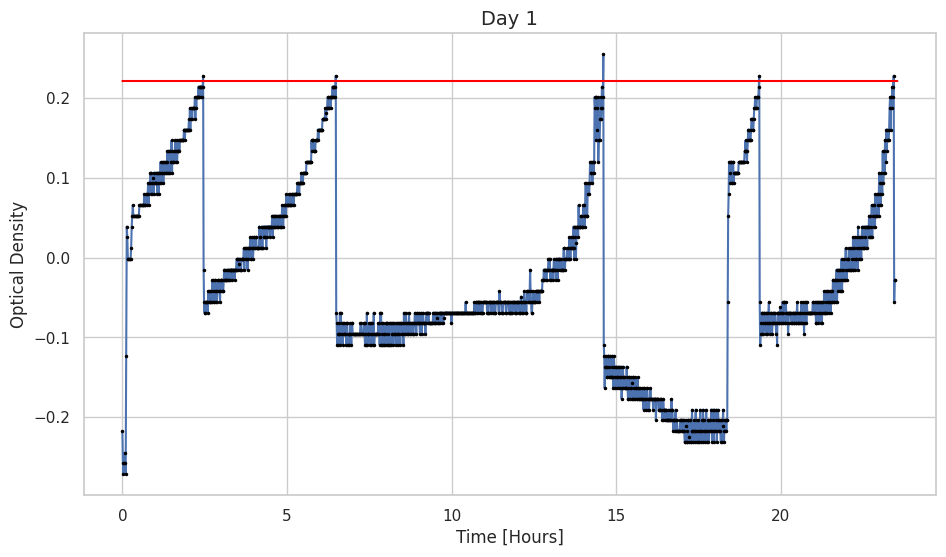

In [90]:

fig,ax= plt.subplots(1,figsize=(11,6))
ax.plot(df_channel7["Time"][:1680],df_channel7["OD"][:1680],marker="o",markersize=1.5, markerfacecolor="black",markeredgecolor="black")
threshold= 0.221*np.ones(len(df_channel7["Time"]))
ax.plot(df_channel7["Time"][:1685],threshold[:1685], color="red")
ax.set_ylabel("Optical Density", fontsize= 12)
ax.set_xlabel("Time [Hours]", fontsize= 12)
ax.set_title("Day 1", fontsize= 14)

# **Optical density plot for the sixth day of the adaptation experiment**

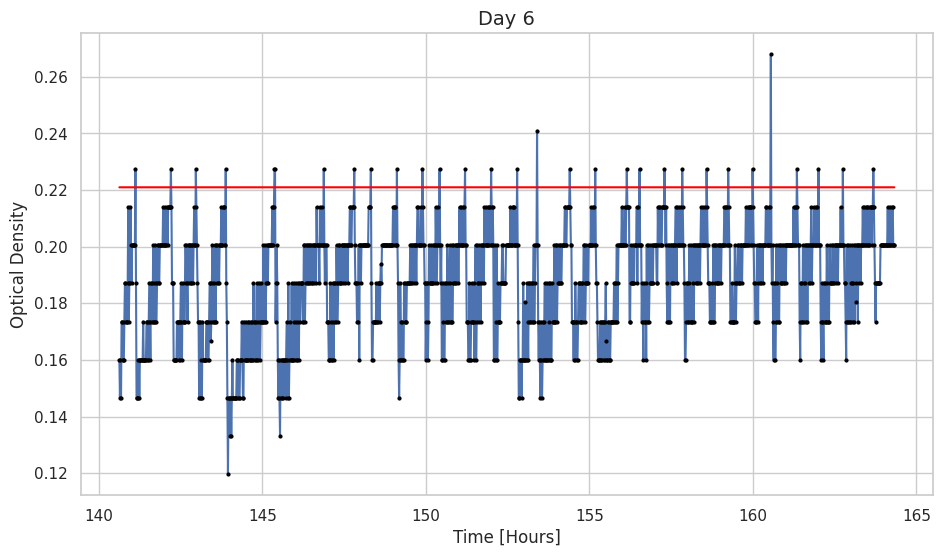

In [91]:
#Plot for day 6 of adaptation experiment
fig,ax= plt.subplots(1,figsize=(11,6))
ax.plot(df_channel7["Time"][9800:11200], df_channel7["OD"][9800:11200],marker="o",markersize=2, markerfacecolor="black",markeredgecolor="black")
threshold= 0.221*np.ones(len(df_channel7["Time"]))
ax.plot(df_channel7["Time"][9800:11200],threshold[9800:11200], color="red")

ax.set_ylabel("Optical Density", fontsize=12)
ax.set_xlabel("Time [Hours]", fontsize= 12)
ax.set_title("Day 6", fontsize=14)
plt.show()

## Looking closely on the data from day six it is posible to see the exponetial growth of the bacterial population. Furthermore, when the optical density goes over the threshold it is posible to see a dramatic drop of the optical density. The former represents the correct behavior of the automatic dilutions performed by the turbidostat.


# **Optical density plot for the eighth day of the adaptation experiment**

Text(0.5, 1.0, 'Day 8')

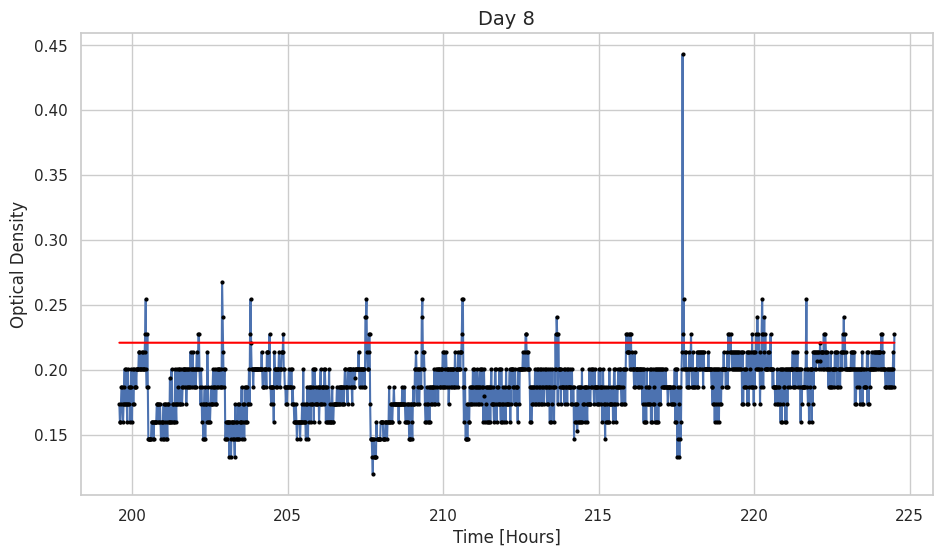

In [65]:
#Plot for day 8 of the adaptation experiment
fig,ax= plt.subplots(1,figsize=(11,6))
ax.plot(df_channel7["Time"][13280:14752],df_channel7["OD"][13280:14752],marker="o",markersize=2, markerfacecolor="black",markeredgecolor="black")
ax.plot(df_channel7["Time"][13280:14752],threshold[13280:14752], color="red")
ax.set_ylabel("Optical Density", fontsize=12)
ax.set_xlabel("Time [Hours]", fontsize= 12)
ax.set_title("Day 8", fontsize=14)

## On the other hand, by day 8 we can start to see that the dilutions start to become progresively more inefective. The optical desity is taking some time to decrease after each dilution. This suggest either external contamination or biofilm formation.

# **Optical density plot for nineth day of the adaptation experiment**

Text(0.5, 1.0, 'Day 9')

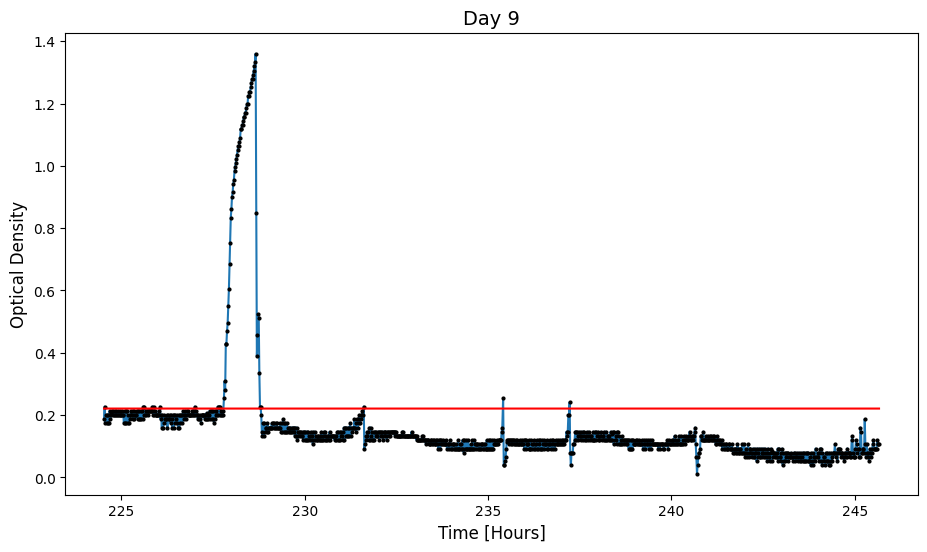

In [35]:
fig,ax= plt.subplots(1,figsize=(11,6))
ax.plot(df_channel7["Time"][14752:16000],df_channel7["OD"][14752:16000],marker="o",markersize=2, markerfacecolor="black",markeredgecolor="black")
ax.plot(df_channel7["Time"][14752:16000],threshold[14752:16000], color="red")
ax.set_ylabel("Optical Density", fontsize=12)
ax.set_xlabel("Time [Hours]", fontsize= 12)
ax.set_title("Day 9", fontsize=14)

# On day 9 optical density incrised drastically and dilutions stoped working temporarely.

# **Optical density plot for the eleventh day of the adaptation experiment**

Text(0.5, 1.0, 'Day 11')

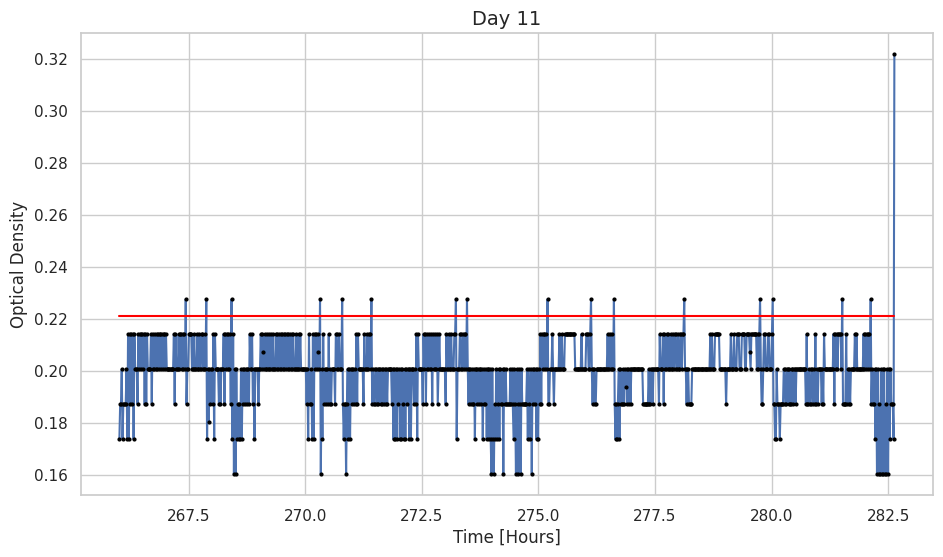

In [61]:
fig,ax= plt.subplots(1,figsize=(11,6))
ax.plot(df_channel7["Time"][17200:18182],df_channel7["OD"][17200:18182],marker="o",markersize=2, markerfacecolor="black",markeredgecolor="black")
ax.plot(df_channel7["Time"][17200:18182],threshold[17200:18182], color="red")
ax.set_ylabel("Optical Density", fontsize=12)
ax.set_xlabel("Time [Hours]", fontsize= 12)
ax.set_title("Day 11", fontsize=14)

In [62]:
#Calculate the number of dilutions over time
d=0
cumulate_time= []
dilutions=[]
for index in df_channel7["Median"].index:
  if df_channel7["Median"][index]<1.5:
    d+=1
    dilutions.append(d)
    cumulate_time.append(df_channel7["Time"][index])


# **Plot for the cumulative number of dilutions over time**

Text(0.5, 0, 'Time [Hours]')

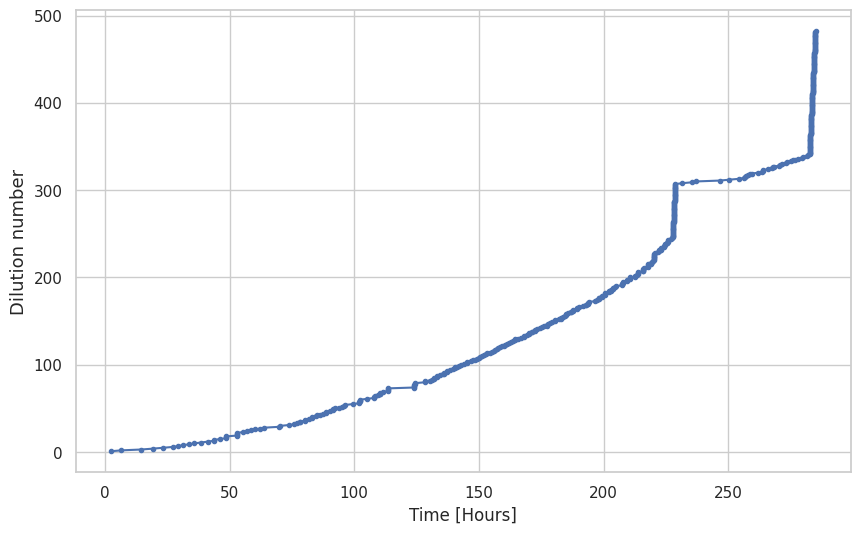

In [68]:
fig,ax= plt.subplots(1,figsize=(10,6))
ax.plot(cumulate_time[:-1],dilutions[:-1],marker="o",markersize=3)
ax.set_ylabel("Dilution number",fontsize=13)
ax.set_xlabel("Time [Hours]", fontsize=12)

## The number of dilutions is working as spected at the begining of the experimente. You can see how the number of the dilutions starts really low and prograsively increases until it drastically increases due to the problem with the effectiveness of the dilutions.

In [57]:
dilution_count = []
dilution_time = []

n = 0
for index in df_channel7["Median"].index:
    if df_channel7["Median"][index] < 1.5:
        n += 1
        dilution_count.append(n)
        dilution_time.append(df_channel7["Time"][index])

# tiempo_diluciones is already in the original time unit (hours), no need to divide by 3600
# tiempo_diluciones = np.array(tiempo_diluciones)/3600 # Se pone el tiempo en horas

t_dilutions = np.diff(dilution_time)


# **Plot for the mean time between dilutions over time**

/tmp/ipykernel_1043/2098032362.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby('window').agg(


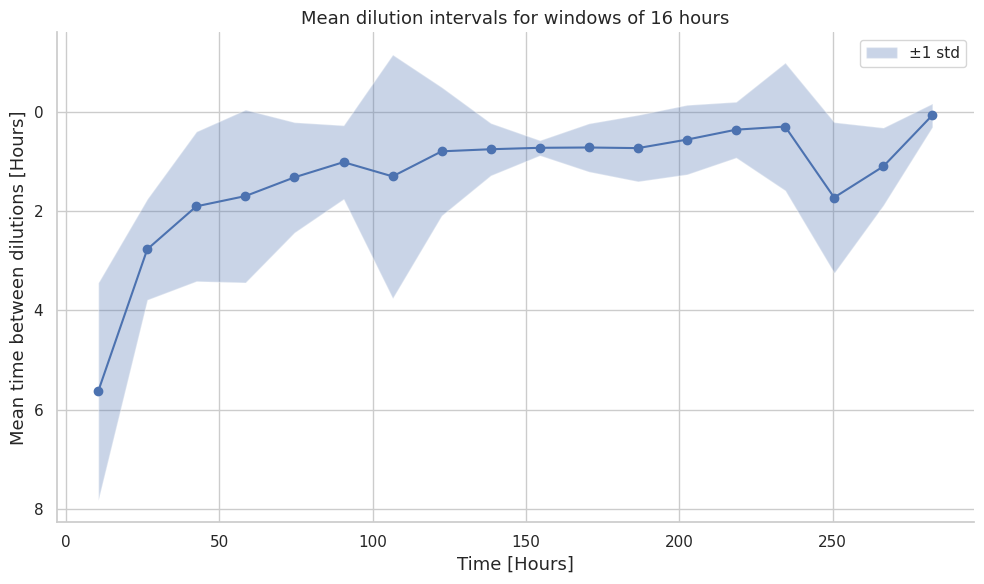

In [60]:
df = pd.DataFrame({
    'total_time': dilution_time[:-1],
    'dilution_interval': t_dilutions
})

# Window size in same units as total_time (hours)
window_size = 16
# Assign each point to a time window
bins = np.arange(df['total_time'].min(), df['total_time'].max() + window_size, window_size)
df['window'] = pd.cut(df['total_time'], bins=bins)
df.at[0, 'window'] = df.at[1, 'window']

# Compute statistics per window
agg = df.groupby('window').agg(
    mean_interval=('dilution_interval', 'mean'),
    std_interval=('dilution_interval', 'std')
)

# Compute window center times
agg['center_time'] = agg.index.map(lambda iv: iv.mid)

# Convert to numeric arrays to avoid dtype issues
center = agg['center_time'].astype(float).values
mean = agg['mean_interval'].astype(float).values
std = agg['std_interval'].astype(float).values


sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))
plt.plot(center, mean, marker='o')
plt.fill_between(center, mean - std, mean + std, alpha=0.3, label='±1 std')
plt.xlabel('Time [Hours]',fontsize=13)
plt.ylabel('Mean time between dilutions [Hours]',fontsize=13)
plt.title(f'Mean dilution intervals for windows of {window_size} hours',fontsize=13)
plt.legend()
sns.despine()
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

## Finally you can see how the mean time between dilutions diminishes suggesting the start of an adaptation process. Then you can see how the mean time between dilutions becomes almost zero as the outomatic dilutions started to fail suggesting biofilm formation. The chart is presented with the y axis inverted to creat a parallel with adaptation curves that are based on fitness.